<a href="https://colab.research.google.com/github/felipe-lim4/analise-exploratoria-alugueis/blob/main/analise_exploratoria_alugueis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise exploratória - Pandas - Aluguéis de imóveis do Rio de Janeiro

In [1]:
import pandas as pd

In [2]:
url = "https://raw.githubusercontent.com/alura-cursos/pandas-conhecendo-a-biblioteca/main/base-de-dados/aluguel.csv"
csv = pd.read_csv(url, sep=';' ) # dados separados por ';' e não por ','.
csv.head()

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
0,Quitinete,Copacabana,1,0,0,40,1700.0,500.0,60.0
1,Casa,Jardim Botânico,2,0,1,100,7000.0,NaN,NaN
2,Conjunto Comercial/Sala,Barra da Tijuca,0,4,0,150,5200.0,4020.0,1111.0
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,NaN


In [3]:
csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32960 entries, 0 to 32959
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Tipo        32960 non-null  object 
 1   Bairro      32960 non-null  object 
 2   Quartos     32960 non-null  int64  
 3   Vagas       32960 non-null  int64  
 4   Suites      32960 non-null  int64  
 5   Area        32960 non-null  int64  
 6   Valor       32943 non-null  float64
 7   Condominio  28867 non-null  float64
 8   IPTU        22723 non-null  float64
dtypes: float64(3), int64(4), object(2)
memory usage: 2.3+ MB


Com o comando .info() do pandasjá possivel notar que grande parte dos dados são numericos, no entanto eles estão irregulares, com a quantidade de linhas menor entre si.

In [4]:
csv.shape #mostra a quantidade de linhas e colunas respectivamente.
# Nisso da para ver claramente que as colunas de Valor do imovel, Condominio e IPTU possuem menos linhas que o maximo do dataframe.

(32960, 9)

Para tratar os dados, é bem melhor que os nomes das colunas não possuam acentuação e estejam todos em lowercase

Além disso, também é possivel observar que dados do tipo object deveriam ser do tipo srt

In [5]:
df = csv.copy()
df.columns = [name.lower() for name in csv.columns.values]
df.head()

,tipo,bairro,quartos,vagas,suites,area,valor,condominio,iptu
0,Quitinete,Copacabana,1,0,0,40,1700.0,500.0,60.0
1,Casa,Jardim Botânico,2,0,1,100,7000.0,NaN,NaN
2,Conjunto Comercial/Sala,Barra da Tijuca,0,4,0,150,5200.0,4020.0,1111.0
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,NaN


In [6]:
df.describe() #Observe um detalhe interessante, que apartamento é esse que tem 100 quartos? Ou pior 1966 vagas?

,quartos,vagas,suites,area,valor,condominio,iptu
count,32960.000000,32960.000000,32960.000000,32960.000000,3.294300e+04,2.886700e+04,2.272300e+04
mean,1.771390,1.749059,0.665777,231.901547,1.295266e+04,2.388062e+03,2.364410e+03
std,1.717869,20.380402,1.176525,1135.254152,6.675220e+05,3.918496e+04,1.795641e+05
min,0.000000,0.000000,0.000000,0.000000,7.500000e+01,1.000000e+00,1.000000e+00
25%,0.000000,0.000000,0.000000,55.000000,1.500000e+03,5.900000e+02,1.100000e+02
50%,2.000000,1.000000,0.000000,87.000000,2.800000e+03,9.900000e+02,2.500000e+02
75%,3.000000,2.000000,1.000000,170.000000,6.500000e+03,1.800000e+03,6.970000e+02
max,100.000000,1966.000000,70.000000,90000.000000,1.200000e+08,6.552570e+06,2.705307e+07


In [7]:
import matplotlib.pyplot as plt

In [8]:
media_geral = df['valor'].mean()
df_valor_medio_tipo = df[['tipo', 'valor']].groupby('tipo').mean().sort_values('valor')
df_valor_medio_tipo

,valor
tipo,
Quitinete,1246.840909
Pousada/Chalé,1480.000000
Casa de Vila,1574.369478
Box/Garagem,1899.756098
Studio,2400.000000
Loft,2557.882353
Flat,4546.189076
Apartamento,4744.614648
Chácara,4900.000000


<Axes: ylabel='tipo'>

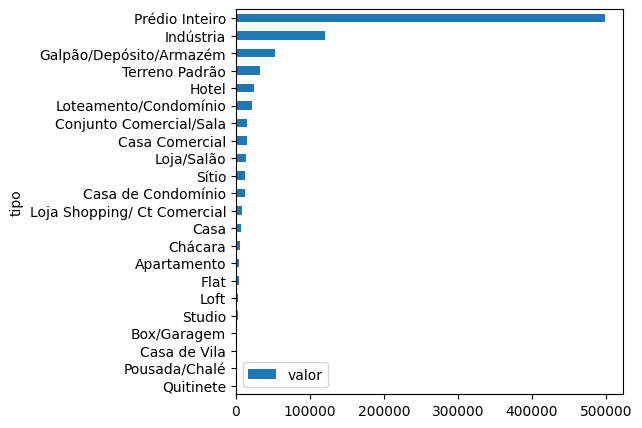

In [9]:
df_preco_tipo = df[['tipo', 'valor']].groupby('tipo').mean().sort_values('valor')
df_preco_tipo.plot(kind='barh', figsize=(5,5))

Agora é possivel identificar de forma mais clara porque havia "casas" com 100 quartos. Aqui a base de dados abrange todos os tipos de imoveis, os comerciais e os residenciais.

In [10]:
valor_imoveis_bairro_apartamento = df.groupby(['bairro', 'tipo'])[['valor']].mean(numeric_only=True)


Bem interessante mostrar que o valor entre os próprios tipos de imóveis variam de preço de acordo com o bairro, então talvez em um futuro treinamento de modelo de regressão seja necessario filtrar e fazer modelos especificos para bairros que possuem maior semelhança de preço e não variam tanto de resultado.

<Axes: xlabel='tipo'>

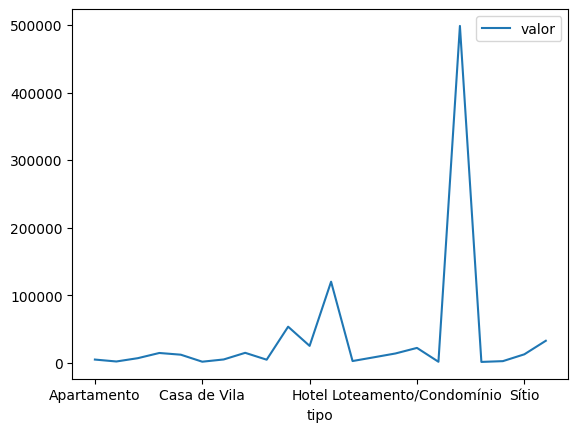

In [11]:
valor_imoveis_por_tipo = df.groupby('tipo')[['valor']].mean()
valor_imoveis_por_tipo.plot(kind='line')

##### Defina um foco!
Como a ideia é poder analisar o preço dos imoveis RESIDENCIAIS, faz bastante sentido remover as colunas de imoveis comerciais, deixando nossa base mais homogenea e linear, possibilitanto o treinamento futuro de um modelo.

In [12]:
list(df.tipo.unique())
imoveis_para_retirada = ['Conjunto Comercial/Sala',

                      'Prédio Inteiro', 'Loja/Salão',

                      'Galpão/Depósito/Armazém',

                      'Casa Comercial', 'Terreno Padrão',

                      'Loja Shopping/ Ct Comercial',

                      'Box/Garagem', 'Chácara',

                      'Loteamento/Condomínio', 'Sítio',

                      'Pousada/Chalé', 'Hotel', 'Indústria']

<Axes: ylabel='tipo'>

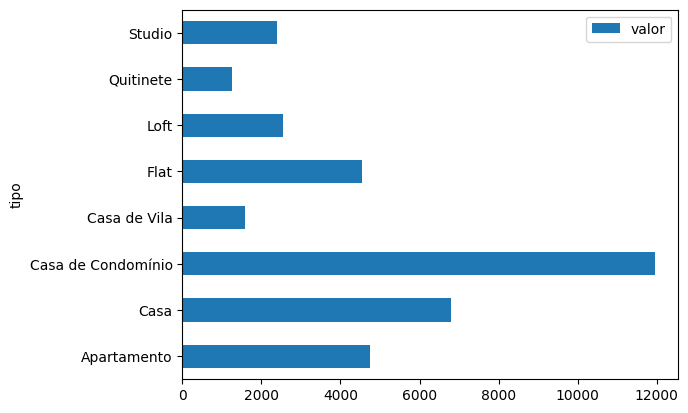

In [13]:
df_filtrados = df.query('@imoveis_para_retirada not in tipo')
dados_agrupados_tipo = df_filtrados.groupby('tipo')[['valor']].mean()
dados_agrupados_tipo.plot(kind='barh')

Com o foco definido, fica nitido que a variação dos dados diminui significativamente. Qual seria o percentual de cada tipo de imovel na nossa base de dados? Para sabermos exatamente qual a sua representatividade na base?

,proportion,percentual
tipo,,
Apartamento,0.845139,84.51
Casa,0.041842,4.18
Casa de Condomínio,0.043096,4.31
Casa de Vila,0.010774,1.08
Flat,0.020596,2.06
Loft,0.002207,0.22
Quitinete,0.036173,3.62
Studio,0.000173,0.02


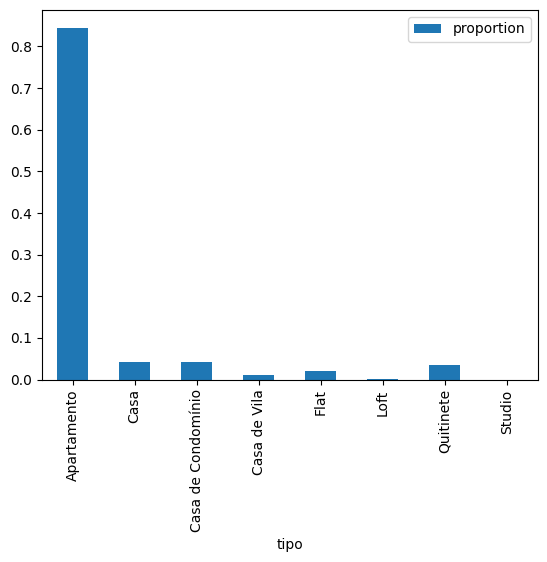

In [14]:
df_filtrados.tipo.unique()
df_filtrados.tipo.value_counts(normalize=True)
df_percentual_tipo= df_filtrados.tipo.value_counts(normalize=True).to_frame().sort_values('tipo')
df_percentual_tipo.plot(kind='bar') # aqui é possivel ver que o percentual de apartamento é extremamente maior do que quando comparado com outros tipos de imóveis
df_percentual_tipo.head()
df_percentual_tipo['percentual'] = round(df_percentual_tipo['proportion'].apply(lambda x: x*100), 2)
df_percentual_tipo

In [15]:
df_filtrados.head()
df.shape

(32960, 9)

### Faz sentido manter o restante dos tipos de imoveis tendo em vista que apartamento se destaca tanto?
Uma pergunta que depende muito da regra de negócio, se fosse realizar um modelo de predição de valores de imoveis, realizar a separação poderia ser bem eficiente, visto que apartamento, casa e casa de condominio por exemplo podem varias muito o preço.

In [16]:
df_apartamentos =  df.query('tipo == "Apartamento"')
df_apartamentos.shape

(19532, 9)

In [17]:
df_apartamentos.head()

,tipo,bairro,quartos,vagas,suites,area,valor,condominio,iptu
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,NaN
5,Apartamento,Vista Alegre,3,1,0,70,1200.0,NaN,NaN
6,Apartamento,Cachambi,2,0,0,50,1300.0,301.0,17.0
10,Apartamento,Centro,1,0,0,36,1200.0,NaN,NaN


In [18]:
media_quartos = df_apartamentos.quartos.mean()

qtd_bairros_unicos = df_apartamentos.bairro.unique()

df_agrupado_bairros = df_apartamentos.groupby('bairro')[['valor']].mean().sort_values('valor', ascending=False)[:5]
print(f'bairros com as maioes médias de aluguel:')
for i, (index, line) in enumerate(df_agrupado_bairros.iterrows()):
  print('\n bairro: ', index, 'valor: ', line.valor)


print(f'media de quartos: {media_quartos} ')
print(f'quantidade de bairros unicos: {len(qtd_bairros_unicos)}')

bairros com as maioes médias de aluguel:

 bairro:  Joá valor:  15500.0

 bairro:  Arpoador valor:  12429.76923076923

 bairro:  Cidade Jardim valor:  12000.0

 bairro:  Ipanema valor:  9487.205316742082

 bairro:  Botafogo valor:  9369.207115628971
media de quartos: 2.481568707761622 
quantidade de bairros unicos: 149


<Axes: xlabel='valor aluguel', ylabel='bairro'>

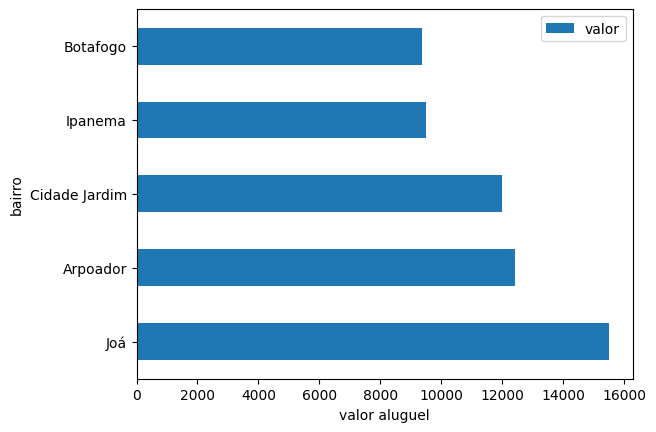

In [19]:
df_agrupado_bairros.plot(kind='barh', xlabel='valor aluguel')

#### Tratamento de dados nulos

In [20]:
df_apartamentos.isnull().sum()
df_apartamentos = df_apartamentos.fillna(0)

In [21]:
df_apartamentos.isnull().sum()

,0
tipo,0
bairro,0
quartos,0
vagas,0
suites,0
area,0
valor,0
condominio,0
iptu,0


##### Retirando valores que não fazem sentido


In [32]:
list_remove = df_apartamentos.query('valor == 0 | condominio == 0').index

In [34]:
df_apartamentos.drop(list_remove, axis=0, inplace=True)

KeyError: '[5, 10, 76, 113, 166, 194, 258, 265, 275, 292, 402, 625, 721, 732, 755, 795, 860, 882, 956, 966, 1007, 1168, 1182, 1186, 1317, 1440, 1458, 1465, 1466, 1488, 1647, 1699, 1734, 1757, 1794, 1903, 1924, 1954, 2085, 2146, 2186, 2239, 2285, 2335, 2406, 2426, 2472, 2489, 2512, 2555, 2584, 2596, 2647, 2648, 2844, 2941, 2971, 2973, 2978, 2984, 2988, 3048, 3111, 3199, 3211, 3218, 3227, 3292, 3332, 3380, 3430, 3530, 3735, 3766, 3770, 3847, 4048, 4058, 4062, 4064, 4159, 4258, 4267, 4286, 4295, 4336, 4347, 4358, 4371, 4414, 4467, 4480, 4515, 4541, 4736, 4757, 4821, 4847, 4957, 4991, 4994, 5029, 5030, 5045, 5047, 5087, 5092, 5178, 5404, 5422, 5438, 5460, 5505, 5516, 5548, 5566, 5604, 5632, 5685, 5711, 5722, 5750, 5856, 5864, 5895, 6000, 6009, 6038, 6047, 6116, 6120, 6127, 6159, 6180, 6223, 6287, 6427, 6495, 6527, 6631, 6684, 6709, 6715, 6719, 6741, 6768, 6769, 6984, 7168, 7218, 7238, 7243, 7263, 7314, 7325, 7362, 7385, 7478, 7520, 7621, 7630, 7675, 7707, 7744, 7753, 7764, 7819, 7822, 7908

In [39]:
df_apartamentos.head()
df_apartamentos.drop('tipo', axis=1, inplace=True)

KeyError: "['tipo'] not found in axis"

In [40]:
df_apartamentos.head()

,bairro,quartos,vagas,suites,area,valor,condominio,iptu
3,Centro,1,0,0,15,800.0,390.0,20.0
4,Higienópolis,1,0,0,48,800.0,230.0,0.0
6,Cachambi,2,0,0,50,1300.0,301.0,17.0
11,Grajaú,2,1,0,70,1500.0,642.0,74.0
12,Lins de Vasconcelos,3,1,1,90,1500.0,455.0,14.0
